# 03 – Train/Test Split & KNN Collaborative Filtering Baseline

This notebook implements a **pure collaborative filtering** KNN recommender system using the Music Taste Profile (user–song play counts) filtered to only the tracks for which MIDI feature files were successfully extracted.

**Pipeline:**
1. Load & filter interactions to songs with MIDI features  
2. 80/20 random user-level train/test hold-out  
3. Sweep KNN (k = 2 … 100) with cosine similarity on the user–item matrix  
4. Evaluate with accuracy + beyond-accuracy metrics  
5. Compute weighted `Overall_Score`

## 1. Imports & Configuration

In [17]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

warnings.filterwarnings("ignore")
np.random.seed(42)

# ── Paths ──────────────────────────────────────────────────────────────────────
ROOT          = Path("..") 
TASTE_PATH    = ROOT / "data/processed/taste_profile_filtered.parquet"
INTERIM_PATH  = ROOT / "data/interim/interim.csv"
LAKH_PATH     = ROOT / "data/processed/lakh_msd_dataset.csv"

# ── Experiment config ──────────────────────────────────────────────────────────
TOP_N         = 10          # recommendation list length
K_RANGE       = range(10, 101, 10)
TEST_SIZE     = 0.20
MIN_SONGS_PER_USER = 5      # discard users with too few interactions (cold-start)
MIN_USERS_PER_SONG = 3      # discard very rare songs

print("All imports OK.")
print(f"Recommending top-{TOP_N} | k sweep: {min(K_RANGE)}–{max(K_RANGE)} | test hold-out: {TEST_SIZE:.0%}")

All imports OK.
Recommending top-10 | k sweep: 10–100 | test hold-out: 20%


## 2. Load & Filter Data

Load interactions, filter to songs that have MIDI feature data, and apply minimum-interaction thresholds to remove cold-start items and users.

In [18]:
# ── 2.1  Load raw data ─────────────────────────────────────────────────────────
print("Loading taste profile …")
taste = pd.read_parquet(TASTE_PATH)          # user_id | song_id | play_count
print(f"  Raw interactions : {len(taste):,}")

print("Loading interim MIDI feature index …")
interim = pd.read_csv(INTERIM_PATH, usecols=["Unnamed: 0"])
interim.rename(columns={"Unnamed: 0": "raw_path"}, inplace=True)
interim["midi_hash"] = interim["raw_path"].apply(
    lambda x: re.search(r"([a-f0-9]{32})\.mid", x).group(1)
    if re.search(r"([a-f0-9]{32})\.mid", x) else None
)
interim.dropna(subset=["midi_hash"], inplace=True)
print(f"  MIDI files indexed: {len(interim):,}")

print("Loading LakhMSD metadata …")
lakh = pd.read_csv(
    LAKH_PATH,
    usecols=["midi_path", "song_id", "artist_name", "title",
             "primary_genre", "song_hotttnesss"]
)
lakh["midi_hash"] = lakh["midi_path"].apply(
    lambda x: re.search(r"([a-f0-9]{32})\.mid", str(x)).group(1)
    if re.search(r"([a-f0-9]{32})\.mid", str(x)) else None
)
lakh.dropna(subset=["midi_hash", "song_id"], inplace=True)

# ── 2.2  Build the set of songs that have MIDI features ────────────────────────
midi_song_ids = set(
    interim.merge(lakh[["midi_hash", "song_id"]], on="midi_hash", how="inner")["song_id"]
)
print(f"\n  Songs with MIDI features : {len(midi_song_ids):,}")

# ── 2.3  Filter interactions to MIDI-covered songs ────────────────────────────
df = taste[taste["song_id"].isin(midi_song_ids)].copy()
print(f"  Interactions after MIDI filter : {len(df):,}")

# ── 2.4  Minimum-interaction thresholds ───────────────────────────────────────
song_counts = df.groupby("song_id")["user_id"].nunique()
valid_songs  = song_counts[song_counts >= MIN_USERS_PER_SONG].index
df = df[df["song_id"].isin(valid_songs)]

user_counts = df.groupby("user_id")["song_id"].nunique()
valid_users  = user_counts[user_counts >= MIN_SONGS_PER_USER].index
df = df[df["user_id"].isin(valid_users)]

print(f"  Interactions after threshold filter : {len(df):,}")
print(f"  Unique users : {df['user_id'].nunique():,}")
print(f"  Unique songs : {df['song_id'].nunique():,}")

# ── 2.5  Encode IDs to integer indices ────────────────────────────────────────
user_ids = sorted(df["user_id"].unique())
song_ids = sorted(df["song_id"].unique())

user2idx = {u: i for i, u in enumerate(user_ids)}
song2idx = {s: i for i, s in enumerate(song_ids)}
idx2song = {i: s for s, i in song2idx.items()}

df["u_idx"] = df["user_id"].map(user2idx)
df["s_idx"] = df["song_id"].map(song2idx)

N_USERS = len(user_ids)
N_SONGS = len(song_ids)
print(f"\nMatrix size: {N_USERS:,} users × {N_SONGS:,} songs")

# Sparsity
sparsity = 1.0 - len(df) / (N_USERS * N_SONGS)
print(f"Sparsity: {sparsity:.4%}")

Loading taste profile …
  Raw interactions : 2,878,032
Loading interim MIDI feature index …
  Raw interactions : 2,878,032
Loading interim MIDI feature index …
  MIDI files indexed: 7,113
Loading LakhMSD metadata …

  Songs with MIDI features : 2,224
  MIDI files indexed: 7,113
Loading LakhMSD metadata …

  Songs with MIDI features : 2,224
  Interactions after MIDI filter : 984,611
  Interactions after MIDI filter : 984,611
  Interactions after threshold filter : 512,525
  Unique users : 68,452
  Unique songs : 1,326
  Interactions after threshold filter : 512,525
  Unique users : 68,452
  Unique songs : 1,326

Matrix size: 68,452 users × 1,326 songs
Sparsity: 99.4353%

Matrix size: 68,452 users × 1,326 songs
Sparsity: 99.4353%


## 3. 80/20 Train / Test Split

For each user we randomly hold out 20 % of their interactions as the test set. Training is done on the remaining 80 %.

In [19]:
def user_level_split(df, test_size=0.20, random_state=42):
    """
    Hold out `test_size` fraction of each user's interactions as test.
    Users with only 1 interaction are kept entirely in train.
    Returns (train_df, test_df).
    """
    train_rows, test_rows = [], []
    rng = np.random.default_rng(random_state)

    for _, grp in df.groupby("u_idx"):
        idxs = grp.index.tolist()
        if len(idxs) < 2:
            train_rows.extend(idxs)
            continue
        n_test = max(1, int(np.floor(len(idxs) * test_size)))
        test_idx  = rng.choice(idxs, size=n_test, replace=False)
        train_idx = list(set(idxs) - set(test_idx))
        train_rows.extend(train_idx)
        test_rows.extend(test_idx)

    return df.loc[train_rows].copy(), df.loc[test_rows].copy()


train_df, test_df = user_level_split(df, test_size=TEST_SIZE)

print(f"Train interactions : {len(train_df):,}  ({len(train_df)/len(df):.1%})")
print(f"Test  interactions : {len(test_df):,}  ({len(test_df)/len(df):.1%})")
print(f"Users in test      : {test_df['u_idx'].nunique():,}")

# Build sparse train matrix  (users × songs, binary implicit feedback)
train_matrix = csr_matrix(
    (np.ones(len(train_df)), (train_df["u_idx"].values, train_df["s_idx"].values)),
    shape=(N_USERS, N_SONGS),
    dtype=np.float32,
)
# L2-normalise rows so cosine similarity ≡ dot product
train_matrix_norm = normalize(train_matrix, norm="l2")

# Ground-truth dict: user → set of held-out song indices
ground_truth = (
    test_df.groupby("u_idx")["s_idx"]
    .apply(set)
    .to_dict()
)
# Also store train songs per user (for novelty)
train_songs_per_user = (
    train_df.groupby("u_idx")["s_idx"]
    .apply(set)
    .to_dict()
)

print("\nData matrices ready.")

Train interactions : 427,276  (83.4%)
Test  interactions : 85,249  (16.6%)
Users in test      : 68,452

Data matrices ready.

Data matrices ready.


## 4. KNN Collaborative Filtering

For each test user:
1. Find k nearest neighbours (cosine similarity on L2-normalised play-count rows)
2. Aggregate neighbour play-counts, masked out already-listened songs
3. Return the top-N songs as the recommendation list

In [20]:
# ── 4.1  Pre-compute popularity (plays in train set) for bias metric ───────────
song_popularity = np.asarray(train_matrix.sum(axis=0)).ravel()   # shape (N_SONGS,)
pop_norm = song_popularity / (song_popularity.max() + 1e-9)      # [0,1]

# ── 4.2  Evaluation helpers ───────────────────────────────────────────────────
def dcg(hits):
    """Discounted Cumulative Gain from a binary relevance list."""
    hits = np.asarray(hits, dtype=float)
    if hits.sum() == 0:
        return 0.0
    positions = np.arange(1, len(hits) + 1)
    return float(np.sum(hits / np.log2(positions + 1)))


def ndcg_at_k(recommended, relevant, k):
    hits = [1 if s in relevant else 0 for s in recommended[:k]]
    ideal = sorted(hits, reverse=True)
    return dcg(hits) / (dcg(ideal) + 1e-9)


def recall_at_k(recommended, relevant, k):
    if not relevant:
        return 0.0
    hits = len(set(recommended[:k]) & relevant)
    return hits / min(len(relevant), k)


def hit_rate_at_k(recommended, relevant, k):
    return float(len(set(recommended[:k]) & relevant) > 0)


def reciprocal_rank(recommended, relevant):
    for rank, s in enumerate(recommended, start=1):
        if s in relevant:
            return 1.0 / rank
    return 0.0


def evaluate_recommendations(recs_dict, ground_truth, train_songs_per_user,
                              song_popularity, n_songs, k=10):
    """
    recs_dict : { u_idx : list of recommended s_idx (ordered, length >= k) }
    Returns a dict of aggregate metrics.
    """
    recalls, ndcgs, hits, rrs = [], [], [], []
    pop_scores, novelty_scores = [], []
    recommended_set = set()

    for u_idx, rec_list in recs_dict.items():
        gt   = ground_truth.get(u_idx, set())
        seen = train_songs_per_user.get(u_idx, set())
        if not gt:
            continue

        top_k = rec_list[:k]
        recalls.append(recall_at_k(top_k, gt, k))
        ndcgs.append(ndcg_at_k(top_k, gt, k))
        hits.append(hit_rate_at_k(top_k, gt, k))
        rrs.append(reciprocal_rank(top_k, gt))

        # Popularity of recommended songs
        if top_k:
            pop_scores.append(float(np.mean(pop_norm[list(top_k)])))

        # Novelty: fraction of recommendations NOT in train
        if top_k:
            novel = [s for s in top_k if s not in seen]
            novelty_scores.append(len(novel) / len(top_k))

        recommended_set.update(top_k)

    coverage = len(recommended_set) / n_songs

    return {
        "Recall@K"        : float(np.mean(recalls)),
        "NDCG@K"          : float(np.mean(ndcgs)),
        "HitRate@K"       : float(np.mean(hits)),
        "MRR"             : float(np.mean(rrs)),
        "Coverage"        : coverage,
        "PopularityBias"  : float(np.mean(pop_scores))  if pop_scores  else 0.0,
        "Novelty"         : float(np.mean(novelty_scores)) if novelty_scores else 0.0,
    }


def overall_score(m):
    """Weighted composite score (PopularityBias already in [0,1])."""
    return (0.35 * m["Recall@K"]
          + 0.35 * m["NDCG@K"]
          + 0.20 * m["Coverage"]
          + 0.10 * (1.0 - m["PopularityBias"]))


print("Helper functions defined.")

Helper functions defined.


In [21]:
def run_knn_cf(k, train_matrix_norm, test_user_indices,
               train_songs_per_user, n_songs, top_n=10):
    """
    Fit a user-based KNN model and generate top-N recommendations
    for every test user.

    Returns recs_dict: { u_idx : [s_idx, ...] }
    """
    # Fit KNN on train rows
    knn = NearestNeighbors(n_neighbors=k + 1, metric="cosine",
                           algorithm="brute", n_jobs=-1)
    knn.fit(train_matrix_norm)

    # Query only test users
    test_vecs = train_matrix_norm[test_user_indices]
    distances, indices = knn.kneighbors(test_vecs, n_neighbors=k + 1)

    recs_dict = {}
    for i, u_idx in enumerate(test_user_indices):
        # Neighbour indices (skip self if present)
        neighbour_idxs = [
            idx for idx in indices[i]
            if idx != u_idx
        ][:k]

        if not neighbour_idxs:
            recs_dict[u_idx] = []
            continue

        # Aggregate neighbour play-counts as scores
        neighbour_matrix = train_matrix_norm[neighbour_idxs]  # (k, N_SONGS)
        scores = np.asarray(neighbour_matrix.sum(axis=0)).ravel()

        # Zero-out already-listened songs
        listened = train_songs_per_user.get(u_idx, set())
        if listened:
            scores[list(listened)] = 0.0

        # Top-N
        top_songs = np.argpartition(scores, -top_n)[-top_n:]
        top_songs = top_songs[np.argsort(scores[top_songs])[::-1]]
        recs_dict[u_idx] = top_songs.tolist()

    return recs_dict


# Test users (those with at least one held-out interaction)
test_user_indices = sorted(ground_truth.keys())
print(f"Evaluating on {len(test_user_indices):,} test users …")
print("This may take a few minutes for the full k sweep.")

Evaluating on 68,452 test users …
This may take a few minutes for the full k sweep.


## 5. K Sweep (k = 2 … 100)

In [22]:
from tqdm.auto import tqdm

results = []

for k in tqdm(K_RANGE, desc="KNN k-sweep"):
    recs = run_knn_cf(
        k=k,
        train_matrix_norm=train_matrix_norm,
        test_user_indices=test_user_indices,
        train_songs_per_user=train_songs_per_user,
        n_songs=N_SONGS,
        top_n=TOP_N,
    )
    metrics = evaluate_recommendations(
        recs_dict=recs,
        ground_truth=ground_truth,
        train_songs_per_user=train_songs_per_user,
        song_popularity=song_popularity,
        n_songs=N_SONGS,
        k=TOP_N,
    )
    metrics["k"] = k
    metrics["Overall_Score"] = overall_score(metrics)
    results.append(metrics)

results_df = pd.DataFrame(results).set_index("k")
print("Sweep complete.")
print(results_df.round(4).to_string())

KNN k-sweep: 100%|██████████| 10/10 [10:12<00:00, 61.23s/it]

Sweep complete.
     Recall@K  NDCG@K  HitRate@K     MRR  Coverage  PopularityBias  Novelty  Overall_Score
k                                                                                         
10     0.3014  0.2195     0.3352  0.1854    0.9035          0.2361   0.9999         0.4394
20     0.3681  0.2657     0.4039  0.2250    0.8198          0.3057   1.0000         0.4552
30     0.4028  0.2872     0.4391  0.2430    0.7459          0.3482   1.0000         0.4559
40     0.4195  0.2984     0.4560  0.2528    0.6652          0.3740   1.0000         0.4469
50     0.4325  0.3070     0.4689  0.2601    0.6109          0.3919   1.0000         0.4418
60     0.4387  0.3104     0.4754  0.2628    0.5671          0.4053   1.0000         0.4351
70     0.4408  0.3125     0.4776  0.2650    0.5339          0.4152   1.0000         0.4289
80     0.4444  0.3141     0.4808  0.2662    0.5068          0.4231   1.0000         0.4245
90     0.4457  0.3156     0.4825  0.2676    0.4842          0.4300   1.000

## 6. Best K & Detailed Report

In [23]:
best_k   = results_df["Overall_Score"].idxmax()
best_row = results_df.loc[best_k]

print("=" * 60)
print(f"  Best k by Overall_Score : k = {best_k}")
print("=" * 60)

pop_label = (
    "low"    if best_row["PopularityBias"] < 0.40 else
    "moderate" if best_row["PopularityBias"] < 0.70 else
    "high"
)
cov_label = (
    "low"    if best_row["Coverage"] < 0.30 else
    "moderate" if best_row["Coverage"] < 0.60 else
    "high"
)

print(f"""
Accuracy Metrics (Top-{TOP_N}):
├─ Recall@{TOP_N}    : {best_row['Recall@K']:.2f}  ({best_row['Recall@K']*100:.0f}% of users' true tracks found in top-{TOP_N})
├─ NDCG@{TOP_N}      : {best_row['NDCG@K']:.2f}  (ranking quality)
├─ Hit Rate@{TOP_N}  : {best_row['HitRate@K']:.2f}  ({best_row['HitRate@K']*100:.0f}% of users got ≥1 song they liked)
└─ MRR          : {best_row['MRR']:.2f}  (users find first hit at avg position {1/best_row['MRR']:.1f})

Beyond-Accuracy Metrics:
├─ Coverage        : {best_row['Coverage']:.2f}  ({best_row['Coverage']*100:.0f}% of {N_SONGS:,} songs recommended, {cov_label})
├─ Popularity Bias : {best_row['PopularityBias']:.2f}  ({pop_label} - normalised [0,1])
└─ Novelty         : {best_row['Novelty']:.2f}  ({best_row['Novelty']*100:.0f}% of recommendations were not already listened tracks)

Weighted Overall Score:
  0.35 × Recall@{TOP_N}  +  0.35 × NDCG@{TOP_N}  +  0.20 × Coverage  +  0.10 × (1 - PopBias)
= 0.35 × {best_row['Recall@K']:.4f}  +  0.35 × {best_row['NDCG@K']:.4f}  +  0.20 × {best_row['Coverage']:.4f}  +  0.10 × {1-best_row['PopularityBias']:.4f}
= {best_row['Overall_Score']:.4f}
""")

# Table: top-5 k values by Overall_Score
print("Top-5 k values by Overall_Score:")
print(results_df.nlargest(5, "Overall_Score")[
    ["Recall@K","NDCG@K","HitRate@K","MRR","Coverage","PopularityBias","Novelty","Overall_Score"]
].round(4).to_string())

  Best k by Overall_Score : k = 30

Accuracy Metrics (Top-10):
├─ Recall@10    : 0.40  (40% of users' true tracks found in top-10)
├─ NDCG@10      : 0.29  (ranking quality)
├─ Hit Rate@10  : 0.44  (44% of users got ≥1 song they liked)
└─ MRR          : 0.24  (users find first hit at avg position 4.1)

Beyond-Accuracy Metrics:
├─ Coverage        : 0.75  (75% of 1,326 songs recommended, high)
├─ Popularity Bias : 0.35  (low - normalised [0,1])
└─ Novelty         : 1.00  (100% of recommendations were not already listened tracks)

Weighted Overall Score:
  0.35 × Recall@10  +  0.35 × NDCG@10  +  0.20 × Coverage  +  0.10 × (1 - PopBias)
= 0.35 × 0.4028  +  0.35 × 0.2872  +  0.20 × 0.7459  +  0.10 × 0.6518
= 0.4559

Top-5 k values by Overall_Score:
    Recall@K  NDCG@K  HitRate@K     MRR  Coverage  PopularityBias  Novelty  Overall_Score
k                                                                                        
30    0.4028  0.2872     0.4391  0.2430    0.7459          0.3482  

## 7. Visualisations

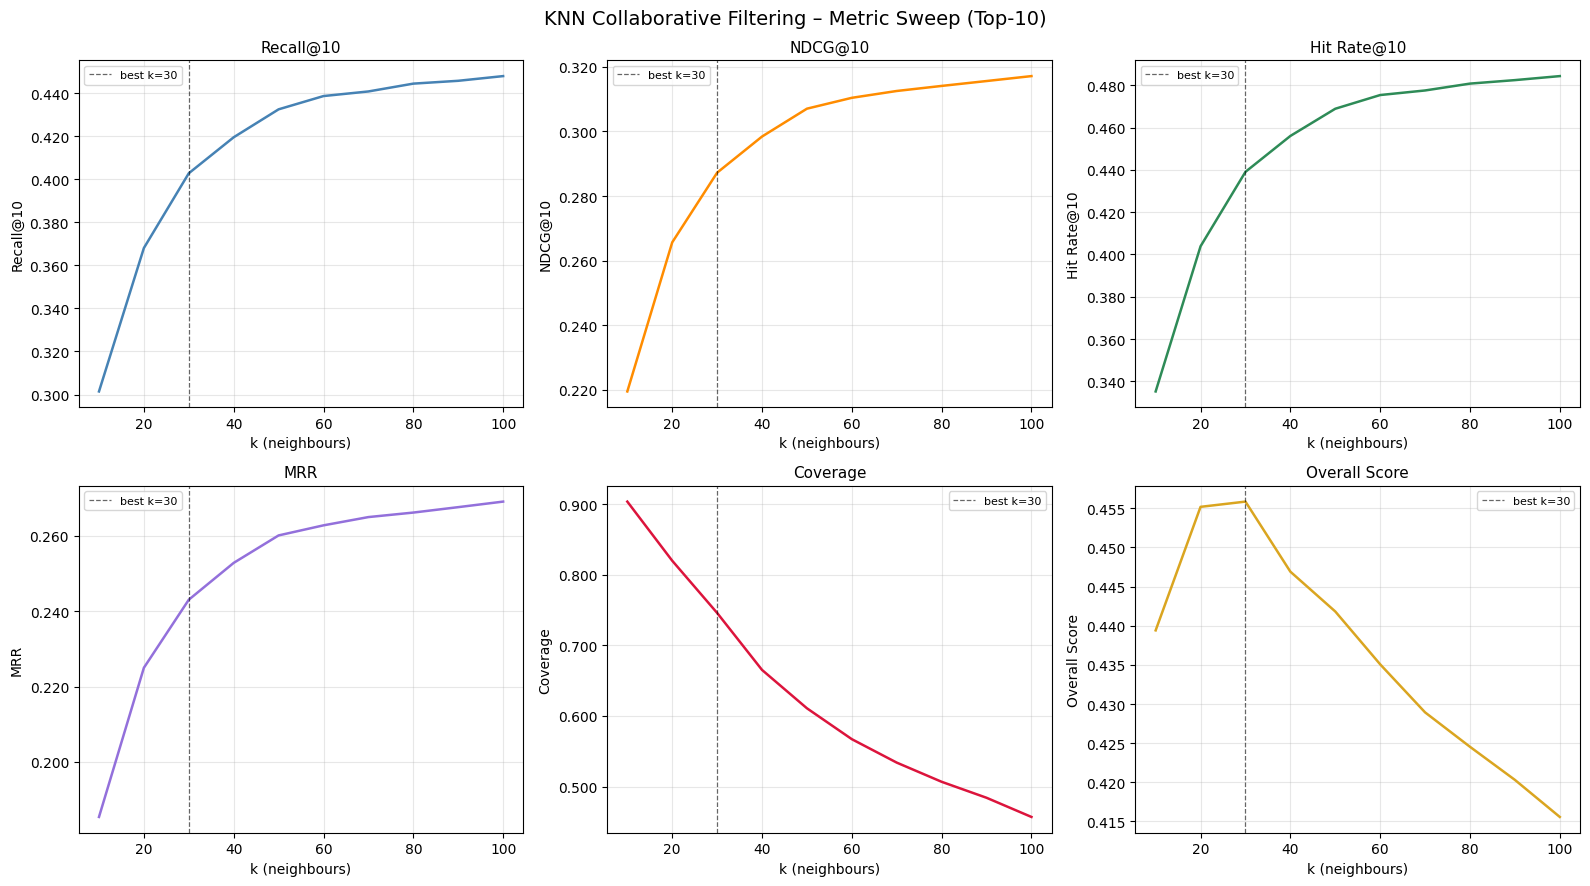

Figure saved as knn_metric_sweep.png


In [24]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle(f"KNN Collaborative Filtering – Metric Sweep (Top-{TOP_N})", fontsize=14)

k_vals = results_df.index.values

metric_cfg = [
    ("Recall@K",       "Recall@10",        "steelblue"),
    ("NDCG@K",         "NDCG@10",          "darkorange"),
    ("HitRate@K",      "Hit Rate@10",      "seagreen"),
    ("MRR",            "MRR",              "mediumpurple"),
    ("Coverage",       "Coverage",         "crimson"),
    ("Overall_Score",  "Overall Score",    "goldenrod"),
]

for ax, (col, label, color) in zip(axes.ravel(), metric_cfg):
    ax.plot(k_vals, results_df[col], color=color, linewidth=1.8)
    ax.axvline(best_k, color="black", linestyle="--", linewidth=0.9, alpha=0.6, label=f"best k={best_k}")
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("k (neighbours)")
    ax.set_ylabel(label)
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.3f"))
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("knn_metric_sweep.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figure saved as knn_metric_sweep.png")

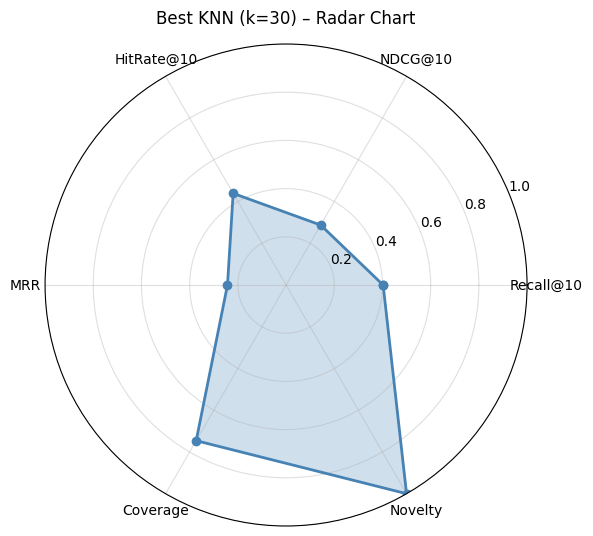

Radar chart saved as knn_best_k_radar.png


In [25]:
# ── Radar chart for best-k metrics ────────────────────────────────────────────
radar_metrics = ["Recall@K", "NDCG@K", "HitRate@K", "MRR", "Coverage", "Novelty"]
radar_labels  = ["Recall@10", "NDCG@10", "HitRate@10", "MRR", "Coverage", "Novelty"]

vals   = [best_row[m] for m in radar_metrics]
angles = np.linspace(0, 2 * np.pi, len(radar_metrics), endpoint=False).tolist()
vals  += vals[:1]
angles += angles[:1]

fig2, ax2 = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax2.plot(angles, vals, "o-", linewidth=2, color="steelblue")
ax2.fill(angles, vals, alpha=0.25, color="steelblue")
ax2.set_thetagrids(np.degrees(angles[:-1]), radar_labels, fontsize=10)
ax2.set_ylim(0, 1)
ax2.set_title(f"Best KNN (k={best_k}) – Radar Chart", pad=15, fontsize=12)
ax2.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("knn_best_k_radar.png", dpi=120, bbox_inches="tight")
plt.show()
print("Radar chart saved as knn_best_k_radar.png")

## 8. Save Results

In [26]:
out_path = ROOT / "data/processed/knn_cf_sweep_results.csv"
results_df.to_csv(out_path)
print(f"Full sweep results saved to: {out_path}")

# Summary row for the best k
summary = {
    "best_k"         : best_k,
    "Recall@10"      : best_row["Recall@K"],
    "NDCG@10"        : best_row["NDCG@K"],
    "HitRate@10"     : best_row["HitRate@K"],
    "MRR"            : best_row["MRR"],
    "Coverage"       : best_row["Coverage"],
    "PopularityBias" : best_row["PopularityBias"],
    "Novelty"        : best_row["Novelty"],
    "Overall_Score"  : best_row["Overall_Score"],
    "n_users"        : N_USERS,
    "n_songs"        : N_SONGS,
    "train_size"     : len(train_df),
    "test_size"      : len(test_df),
}
pd.DataFrame([summary]).to_csv(ROOT / "data/processed/knn_cf_best_k_summary.csv", index=False)
print("Best-k summary saved to: data/processed/knn_cf_best_k_summary.csv")

Full sweep results saved to: ../data/processed/knn_cf_sweep_results.csv
Best-k summary saved to: data/processed/knn_cf_best_k_summary.csv
